# Step 1: Descriptive Statistics & Univariate Analysis 

In [48]:
# load the cleaned dataset (i.e ApexPlanet_cleaned_dataset).
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('D:/Vscode Project/Apexplanet/ApexPlanet_cleaned_Dataset.xlsx', sheet_name='Cleaned_Data')

In [49]:
# Statistics Summary of Numerical values
summary = df[['Age','Quantity','Unit_Price','Total_Sales']].describe()
print(summary)

              Age     Quantity    Unit_Price    Total_Sales
count  980.000000  1000.000000   1000.000000    1000.000000
mean    41.360204     5.435000  25486.783410  139399.439650
std     13.822597     2.838632  14179.402361  114100.051546
min     18.000000     1.000000    145.780000     437.340000
25%     30.000000     3.000000  13895.722500   47066.632500
50%     41.000000     5.000000  25398.740000  108594.025000
75%     54.000000     8.000000  37512.382500  203722.882500
max     65.000000    10.000000  49997.530000  493677.500000


In [50]:
# Frequency of Categorical Columns:
for col in ['Gender','City','Product','Category']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Gender:
Gender
Male      511
Female    489
Name: count, dtype: int64

City:
City
Patna        135
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
Name: count, dtype: int64

Product:
Product
Mobile    184
Book      178
Laptop    170
Chair     159
Shoes     156
Rice      153
Name: count, dtype: int64

Category:
Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64


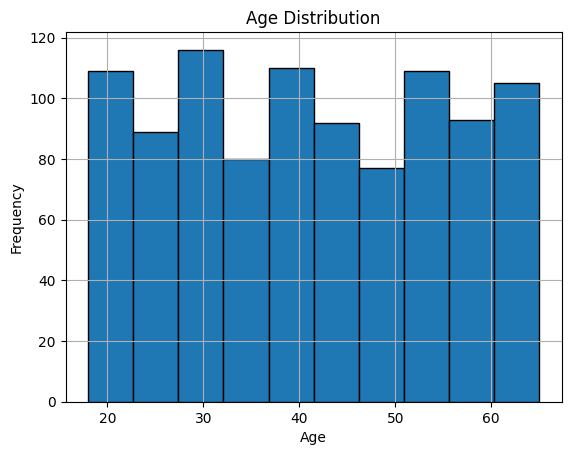

In [51]:
#Visualization --- Histogram (Numerical Data)
df['Age'].hist(bins=10, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('age_histogram.png')
plt.show()

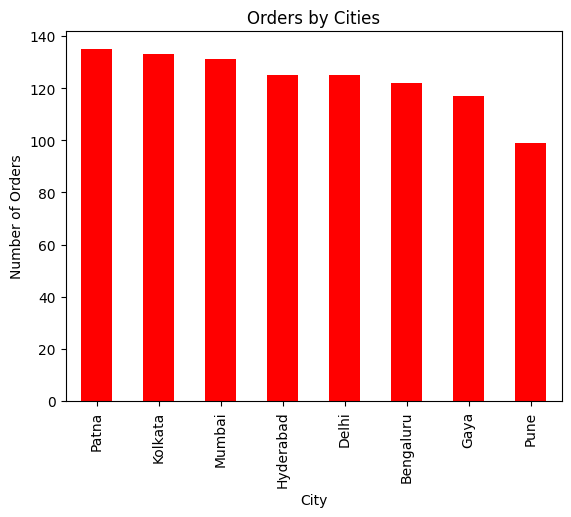

In [52]:
#Visualization ---- Bar Chart (Categorical Data)
df['City'].value_counts().plot(kind='bar', color='red')
plt.title('Orders by Cities')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.savefig('city_barchart.png')
plt.show()

# Step 2: SQL for Business Questions

In [ ]:
import sqlite3

df = pd.read_excel(r"D:\Vscode Project\Apexplanet\ApexPlanet_Cleaned_Dataset.xlsx",sheet_name='Cleaned_Data')

conn = sqlite3.connect(':memory:')
df.to_sql('sales',conn , index=False, if_exists = 'replace')

In [56]:
#making a helper 

def run_query(query):
    return pd.read_sql_query(query, conn)

In [59]:
run_query("SELECT * FROM sales LIMIT 5")

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Month,Order_Year,Age_Group
0,ORD100002,2025-02-25 00:00:00,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2,2025,26-35
1,ORD100003,2025-10-14 00:00:00,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,10,2025,56-65
2,ORD100004,2025-05-13 00:00:00,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,5,2025,56-65
3,ORD100005,2025-12-02 00:00:00,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,12,2025,56-65
4,ORD100006,2025-11-20 00:00:00,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,11,2025,36-45


In [60]:
#aggregation
q1 = """ 
SELECT Product, SUM(Total_sales) AS Total_Revenue
FROM sales
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 5
"""
run_query(q1)

,Product,Total_Revenue
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48


In [63]:
city_region = pd. DataFrame({
    'CITY': ['Patna','Kolkata','Mumbai','Hyderabad','Delhi','Bengaluru','Gaya','Pune','Unknown'],
    'Region': ['East','East','West','South',' North','South','East','West','Unknown']
})
city_region.to_sql('city_region', conn, index = False, if_exists = 'replace')

q_join= """
SELECT cr.Region, SUM(s.Total_Sales) AS Total_Revenue
FROM sales s
JOIN city_region cr ON s.City = cr.City
GROUP BY cr.Region
ORDER BY Total_Revenue DESC
"""
run_query(q_join)

,Region,Total_Revenue
0,East,52551175.85
1,South,35940341.19
2,West,33270226.07
3,North,16097079.00


# Questions

In [66]:
#Q1 What are the top 5 Products by total revenue?
SELECT Product, SUM(Total_Sales) as Total_Revenue
From sales
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 5;

SyntaxError: invalid syntax (764656705.py, line 2)